
<div style="padding:24px 26px;border-radius:14px;background:linear-gradient(135deg,#16324F,#2F6F7E);margin-bottom:20px;box-shadow:0 6px 18px rgba(22,50,79,0.14);">
<h1 style="margin:0;color:white;font-size:34px;">Cardiac Patient Monitoring System</h1>
<p style="margin:8px 0 0 0;color:#EAF3F5;font-size:18px;">Milestone 1 — Understanding the Data</p>
<p style="margin:6px 0 0 0;color:#DDECEF;font-size:14px;">Heart Disease Cleveland Dataset · Data Understanding & Quality Check</p>
</div>



<div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:12px;padding:18px 20px;margin:12px 0 18px 0;">
<h2 style="color:#16324F;margin-top:0;">Introduction</h2>
<p style="color:#3F4A52;">This project starts with the <b>Heart Disease Cleveland dataset</b>, which contains clinical information for patients that may be related to heart disease.</p>
<p style="color:#3F4A52;">Before moving into modeling, I first want to understand the patients represented in the dataset and check whether the available information is reliable enough for later analysis.</p>
<p style="color:#3F4A52;">The dataset contains <b>303 patient records</b>, described by <b>13 input features</b>, while the <code>target</code> column represents the outcome that will later be predicted.</p>
<div style="background:#F6F9FA;border-left:4px solid #2F6F7E;border-radius:8px;padding:13px 15px;margin-top:14px;">
<p style="color:#16324F;font-weight:bold;margin-top:0;">Main Question</p>
<p style="color:#3F4A52;margin-bottom:0;">Is the data itself ready to be trusted before machine learning begins?</p>
</div>
</div>



<div style="background:#F6F9FA;border:1px solid #DCE5E8;border-radius:12px;padding:16px 18px;margin:12px 0 20px 0;">
<p style="color:#16324F;font-weight:bold;font-size:18px;margin-top:0;">Milestone 1 Roadmap</p>
<div style="display:flex;flex-wrap:wrap;align-items:center;gap:8px;color:#3F4A52;">
<span style="background:white;padding:8px 12px;border-radius:8px;">Load Data</span>
<span style="color:#2F6F7E;font-weight:bold;">→</span>
<span style="background:white;padding:8px 12px;border-radius:8px;">Inspect Structure</span>
<span style="color:#2F6F7E;font-weight:bold;">→</span>
<span style="background:white;padding:8px 12px;border-radius:8px;">Check Quality</span>
<span style="color:#2F6F7E;font-weight:bold;">→</span>
<span style="background:white;padding:8px 12px;border-radius:8px;">Validate Values</span>
<span style="color:#2F6F7E;font-weight:bold;">→</span>
<span style="background:#DDECEF;padding:8px 12px;border-radius:8px;color:#16324F;font-weight:bold;">Save Checked Data</span>
</div>
</div>


<h2 style="color:#16324F;font-weight:bold;">Environment</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">This project is developed in Jupyter Notebook using Python with Pandas, NumPy, Matplotlib, and Scikit-learn.</p></div>

In [163]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python version: 3.12.13
Pandas version: 3.0.3
NumPy version: 2.5.1


<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:12px;
    padding:16px 18px;
    margin:12px 0 18px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:18px;
    margin:0 0 12px 0;
">
Dataset Source
</p>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:9px;
    padding:13px 15px;
    margin-bottom:12px;
">

<p style="
    color:#3F4A52;
    margin:0 0 10px 0;
    line-height:1.7;
">
The dataset used in this project is the <b>Heart Disease Cleveland Dataset</b>, obtained from Kaggle for educational machine-learning analysis.
</p>

<p style="
    color:#3F4A52;
    margin:0;
">
<b>Source:</b>
<a href="https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland" target="_blank">
Kaggle — Heart Disease Cleveland Dataset
</a>
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:9px;
    padding:13px 15px;
">

<p style="
    color:#16324F;
    font-weight:bold;
    margin:0 0 8px 0;
">
Why This Dataset?
</p>

<div style="
    color:#3F4A52;
    line-height:1.8;
">
• It provides a clear <b>binary classification problem</b> using the <code>target</code> column.<br><br>

• It contains several patient-related features that can be explored before model training.<br><br>

• Its size makes it suitable for clear analysis while still supporting a complete supervised machine-learning workflow.<br><br>

• It is suitable for <b>EDA, classification, model comparison, cross-validation, feature engineering, and Pipeline construction</b>.
</div>

</div>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">1. Loading the Dataset</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Before changing or cleaning anything, I want to see the data exactly as it was provided.</p></div>

In [164]:
# Load the Cleveland Heart Disease dataset
df = pd.read_csv("../data/Heart_disease_cleveland_new.csv")

# Display the first five patient records
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">The first rows show that the dataset contains both numerical measurements and features represented using numeric codes. The <code>target</code> column is also included and will later be used as the outcome for the classification task.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">2. How Large Is the Dataset?</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Knowing the number of patient records and columns gives a clearer picture of the amount of data available for the analysis.</p></div>

In [165]:
# Check the number of rows and columns
df.shape

(303, 14)

<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">The dataset contains <b>303 patient records and 14 columns</b>. Among these columns, <b>13 are input features</b> and <code>target</code> is the outcome for classification.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">3. What Information Does Each Patient Record Contain?</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Next, I will inspect the available columns to understand what type of information is stored for each patient.</p></div>

In [166]:
# Display all column names
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">The dataset contains 13 patient features and one target column. Some columns contain direct numerical measurements, while others use numbers to represent categories.</p></div>


<h2 style="color:#2F6F7E;font-weight:bold;">4. Data Dictionary</h2>

| Feature | Description |
|---|---|
| `age` | Age of the patient in years |
| `sex` | Sex of the patient: 0 = female, 1 = male |
| `cp` | Chest pain type: 0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic |
| `trestbps` | Resting blood pressure in mm Hg |
| `chol` | Serum cholesterol in mg/dl |
| `fbs` | Fasting blood sugar > 120 mg/dl: 0 = false, 1 = true |
| `restecg` | Resting ECG result: 0 = normal, 1 = ST-T abnormality, 2 = left ventricular hypertrophy |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina: 0 = no, 1 = yes |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak exercise ST segment: 0 = upsloping, 1 = flat, 2 = downsloping |
| `ca` | Number of major vessels |
| `thal` | Thal result: 1 = normal, 2 = fixed defect, 3 = reversible defect |
| `target` | Heart disease status: 0 = absence, 1 = presence |


<h2 style="color:#2F6F7E;font-weight:bold;">5. Checking the Dataset Structure</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Before cleaning the data, I want to inspect the data types and make sure each column contains the expected number of values.</p></div>

In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">All 14 columns contain 303 non-null values. Most columns are stored as integers, while <code>oldpeak</code> is stored as a float because it contains decimal values.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">
6. Are There Any Missing Values?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Check Missing Values?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Missing values can affect both data analysis and model training.
<br><br>
Before moving to later steps, I need to confirm that every patient record contains complete information.
</p>

</div>

</div>

In [168]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">All columns have <b>0 missing values</b>, so the dataset is complete according to this check.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">
7. Are There Any Duplicate Records?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Check Duplicate Records?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Duplicate records can cause the same observation to be counted more than once and may affect later analysis or model evaluation.
<br><br>
I will check whether any patient rows are repeated before continuing with the dataset.
</p>

</div>

</div>

In [169]:
df.duplicated().sum()

np.int64(0)

<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">No duplicate rows were found, so no records need to be removed for duplication.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">8. Are the Values Reasonable?</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">I will inspect the unique values of the coded categorical features to make sure they match the expected categories.</p></div>

In [170]:
categorical_col = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal", "target"
]

for column in categorical_col:
    print(f"{column}: {sorted(df[column].unique())}")

sex: [np.int64(0), np.int64(1)]
cp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fbs: [np.int64(0), np.int64(1)]
restecg: [np.int64(0), np.int64(1), np.int64(2)]
exang: [np.int64(0), np.int64(1)]
slope: [np.int64(0), np.int64(1), np.int64(2)]
ca: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
thal: [np.int64(1), np.int64(2), np.int64(3)]
target: [np.int64(0), np.int64(1)]


<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;margin-bottom:0;">The coded features contain the expected category values. Binary features such as <code>sex</code>, <code>fbs</code>, <code>exang</code>, and <code>target</code> contain only 0 and 1.</p></div>

<h2 style="color:#2F6F7E;font-weight:bold;">9. Checking Numerical Ranges</h2><div style="background:#ffffff;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 14px 0;"><p style="color:#3F4A52;margin:0;">Next, I will inspect the numerical measurements and check whether their ranges look reasonable.</p></div>

In [171]:
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


<div style="background:#EAF3F5;border:1px solid #D5E5E9;border-radius:9px;padding:14px 16px;margin:10px 0 18px 0;"><p style="color:#2F6F7E;font-weight:bold;margin-top:0;">Observation</p><p style="color:#3F4A52;">Patient ages range from <b>29 to 77 years</b>, resting blood pressure from <b>94 to 200 mm Hg</b>, cholesterol from <b>126 to 564 mg/dl</b>, and maximum heart rate from <b>71 to 202 bpm</b>.</p><p style="color:#3F4A52;margin-bottom:0;">Some high values stand out, but I will keep them for now and examine them during EDA instead of removing them without evidence.</p></div>


<h2 style="color:#2F6F7E;font-weight:bold;">10. Initial Cleaning Decision</h2>
<div style="background:#F6F9FA;border:1px solid #DCE5E8;border-radius:10px;padding:14px 16px;margin:10px 0 16px 0;">
<p style="color:#16324F;font-weight:bold;margin-top:0;">Cleaning Summary</p>
<ul style="color:#3F4A52;margin-bottom:0;">
<li>No missing values were found.</li>
<li>No duplicate rows were found.</li>
<li>The categorical codes matched the expected values.</li>
<li>The numerical values looked reasonable overall.</li>
<li>Some high values were kept for later EDA instead of being removed without evidence.</li>
</ul>
</div>


In [172]:
df.to_csv("../data/heart_cleveland_checked.csv", index=False)


<h2 style="color:#16324F;font-weight:bold;">Milestone 1 Takeaway</h2>
<div style="background:linear-gradient(135deg,#F8FBFC,#EAF3F5);border:1px solid #D5E5E9;border-radius:12px;padding:16px 18px;margin:10px 0 18px 0;">
<ul style="color:#3F4A52;margin-bottom:0;">
<li>The dataset contains <b>303 patient records</b>, <b>13 input features</b>, and one target column.</li>
<li>No missing values or duplicate records were found.</li>
<li>The coded categorical values matched the expected categories.</li>
<li>The numerical ranges looked reasonable overall, so no records were removed at this stage.</li>
<li>The checked dataset was saved and is ready for the next milestone: exploratory data analysis.</li>
</ul>
</div>


<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 2 — Exploratory Data Analysis & Statistics
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
Understanding patient patterns before model training
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52;margin:0;">
With the dataset checked and ready, I can now explore patient patterns, relationships, and possible outliers before moving to model training.
</p>

</div>

<h2 style="
    color:#2F6F7E;
    font-weight:bold;
">
1. Target Distribution and Class Balance
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Check Class Balance First?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Before analyzing the patient features, I first need to understand how the target classes are distributed.
<br><br>
A strong class imbalance can affect model evaluation and may cause a classifier to favor one class over the other.
<br><br>
So the first question is: <b>Are heart disease and no-heart-disease cases reasonably balanced in this dataset?</b>
</p>

</div>

</div>

In [173]:
# Count patients in each target class
target_counts = df["target"].value_counts()

# Calculate the proportion of each class
target_proportions = df["target"].value_counts(normalize=True)
print("Target Counts:")
print(target_counts)
print("\nTarget Proportions:")
print(target_proportions)

Target Counts:
target
0    164
1    139
Name: count, dtype: int64

Target Proportions:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


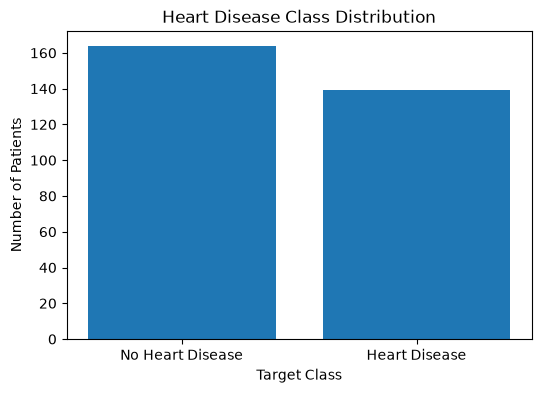

In [174]:
# Plot the target distribution
plt.figure(figsize=(6, 4))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    target_counts.values
)

plt.xlabel("Target Class")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Class Distribution")

plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The dataset contains 164 patients without heart disease and 139 patients with heart disease. The difference between the two classes is only 25 patients, so the target distribution is fairly balanced.
</p>

<h2 style="color:#2F6F7E;font-weight:bold;">
2. Descriptive Statistics
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Use Descriptive Statistics?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Before visualizing the numerical features, I want to summarize their typical values and variability.
<br><br>
The <b>mean</b> and <b>median</b> help describe the center of each feature, while the <b>standard deviation</b> shows how much the values vary.
<br><br>
Comparing these statistics also helps identify features that may be skewed or contain unusually high or low values.
</p>

</div>

In [175]:
# Select the main continuous numerical features
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Show descriptive statistics
df[numerical_features].describe().round(2)

,age,trestbps,chol,thalach,oldpeak
count,303.00,303.00,303.00,303.00,303.00
mean,54.44,131.69,246.69,149.61,1.04
std,9.04,17.60,51.78,22.88,1.16
min,29.00,94.00,126.00,71.00,0.00
25%,48.00,120.00,211.00,133.50,0.00
50%,56.00,130.00,241.00,153.00,0.80
75%,61.00,140.00,275.00,166.00,1.60
max,77.00,200.00,564.00,202.00,6.20


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The average patient age is about <b>54 years</b>, with most patients falling between <b>48 and 61 years</b>.<br><br>
Resting blood pressure has a mean of about <b>132 mm Hg</b>, while cholesterol has a mean of about <b>247 mg/dl</b> and shows a wider spread, reaching a maximum of <b>564 mg/dl</b>.<br><br>
The average maximum heart rate is about <b>150 bpm</b>, and <code>oldpeak</code> has a median of <b>0.80</b> but reaches as high as <b>6.20</b>, which suggests that some values may need closer inspection later.
</p>

In [176]:
# Calculate mean, median, and standard deviation
statistics_summary = pd.DataFrame({
    "Mean": df[numerical_features].mean(),
    "Median": df[numerical_features].median(),
    "Std": df[numerical_features].std()
}).round(2)

statistics_summary

,Mean,Median,Std
age,54.44,56.0,9.04
trestbps,131.69,130.0,17.60
chol,246.69,241.0,51.78
thalach,149.61,153.0,22.88
oldpeak,1.04,0.8,1.16


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The mean and median are fairly close for <code>age</code>, <code>trestbps</code>, and <code>thalach</code>, which suggests that these features are not strongly skewed.<br><br>
For <code>chol</code> and <code>oldpeak</code>, the mean is higher than the median. This may indicate some higher values pulling the average upward.<br><br>
<code>chol</code> also has the largest standard deviation at about <b>51.78</b>, showing that cholesterol values vary more than the other features in this summary.
</p>

<h2 style="color:#2F6F7E;">3. Numerical Feature Distributions</h2>

<p style="color:#3F4A52;">
Now I will visualize the main numerical features to see how their values are distributed across the patients.
</p>

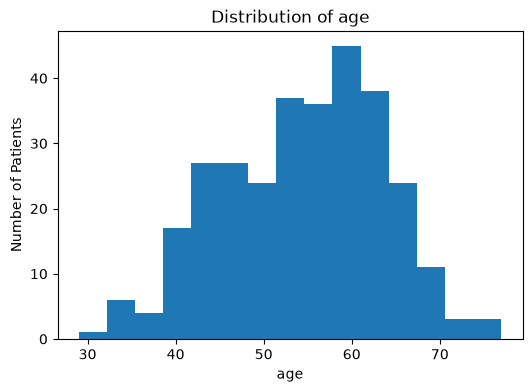

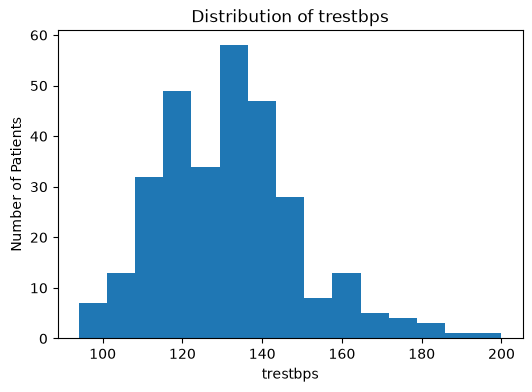

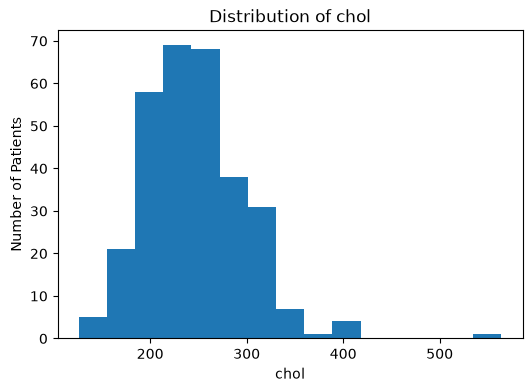

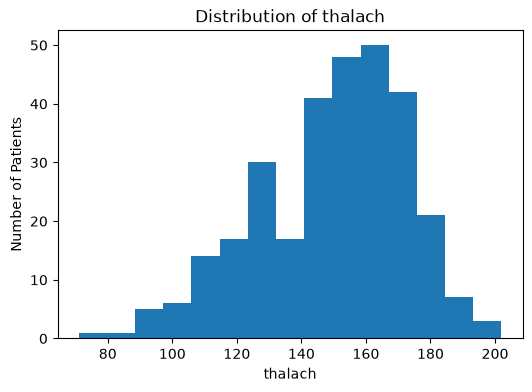

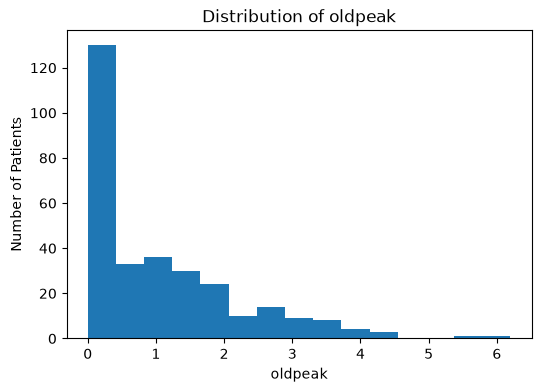

In [177]:
# Plot distributions one by one
for feature in numerical_features:
    plt.figure(figsize=(6, 4))

    plt.hist(
        df[feature],
        bins=15
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.title(f"Distribution of {feature}")

    plt.show()

<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The <code>age</code> distribution is concentrated mostly between the late 40s and early 60s.<br><br>

<code>trestbps</code> is centered around the 120–140 mm Hg range, with a smaller number of patients having much higher values.<br><br>

<code>chol</code> is more right-skewed than the other features, with most values around 200–300 mg/dl and a few very high values above 400 mg/dl.<br><br>

<code>thalach</code> is concentrated mainly between about 140 and 170 bpm, with fewer patients at the very low or very high ends.
</p>

<h2 style="color:#2F6F7E;font-weight:bold;">
4. Which Features Look Different Between the Two Patient Groups?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
Now that I understand the overall distributions, I want to compare the main numerical features between patients with and without heart disease.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Do patients with heart disease show noticeably different values in age, cholesterol, resting blood pressure, maximum heart rate, or oldpeak?
</p>

</div>

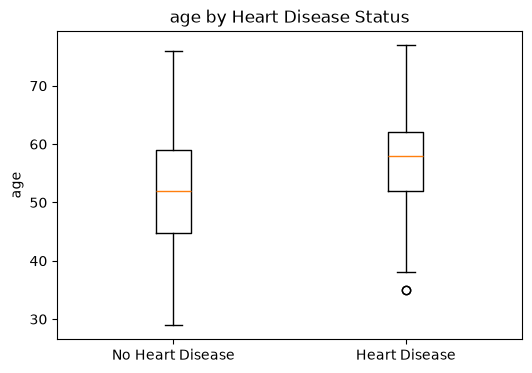

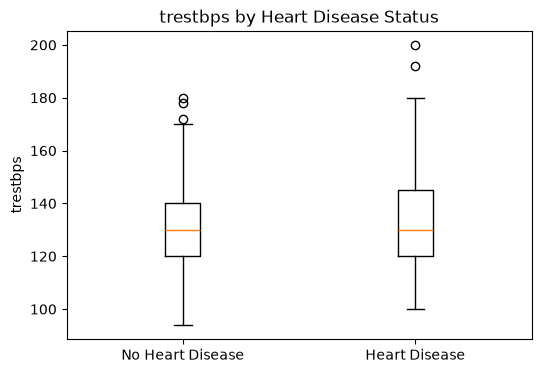

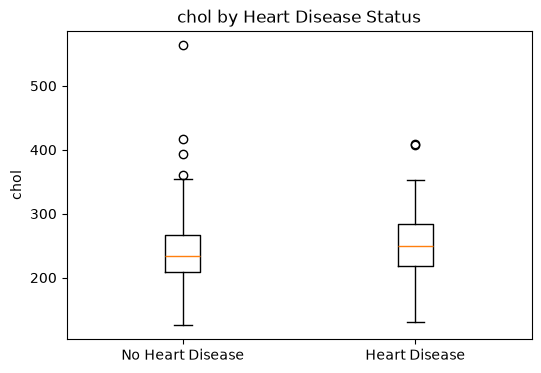

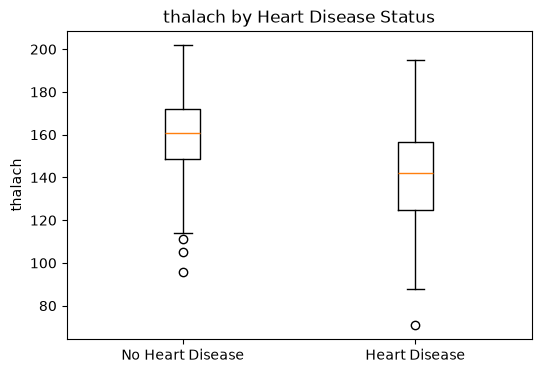

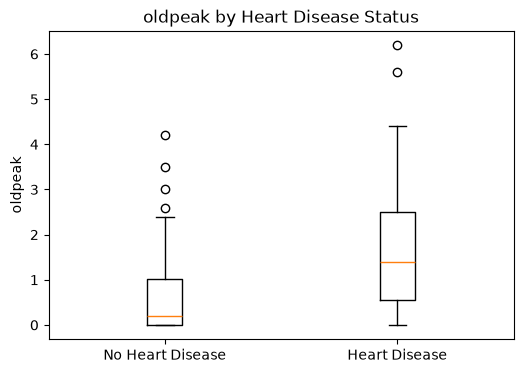

In [178]:


# Compare numerical features between the two target groups
for feature in numerical_features:
    plt.figure(figsize=(6, 4))

    group_0 = df[df["target"] == 0][feature]
    group_1 = df[df["target"] == 1][feature]

    plt.boxplot(
        [group_0, group_1],
        tick_labels=["No Heart Disease", "Heart Disease"]
    )

    plt.ylabel(feature)
    plt.title(f"{feature} by Heart Disease Status")

    plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="color:#3F4A52;">
The boxplots show several noticeable differences between the two patient groups.
</p>

<ul style="color:#3F4A52; line-height:1.7; margin-bottom:0;">

<li>
Patients with heart disease tend to be <b>older</b>, with a higher median age than patients without heart disease.
</li>

<li>
Resting blood pressure (<code>trestbps</code>) is fairly similar between the two groups, although several high values appear as outliers.
</li>

<li>
Cholesterol (<code>chol</code>) shows only a small difference between the groups and contains some unusually high values.
</li>

<li>
Maximum heart rate (<code>thalach</code>) is noticeably <b>lower</b> for patients with heart disease.
</li>

<li>
<code>oldpeak</code> is clearly <b>higher</b> in the heart disease group, making it one of the strongest visible differences in this comparison.
</li>

</ul>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Next Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The boxplots show which features differ between the two groups, but do these features also move together or show a measurable relationship with the target?
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
5. Which Features Are Most Related to Heart Disease?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Use Correlation Analysis?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The previous plots showed visible differences between the two patient groups, but I also want a numerical measure of how strongly each feature is related to the target.
<br><br>
Correlation helps show the <b>direction</b> and <b>strength</b> of these relationships.
<br><br>
I will use it as an exploratory measure only, because correlation can highlight associations but does not prove that one feature causes heart disease.
</p>

</div>

</div>

In [179]:
# Calculate correlations between all numerical columns
correlation_matrix = df.corr(numeric_only=True)

# Show correlations with the target
target_correlations = (
    correlation_matrix["target"]
    .drop("target")
    .sort_values()
)

target_correlations

thalach    -0.417167
fbs         0.025264
chol        0.085164
trestbps    0.150825
restecg     0.169202
age         0.223120
sex         0.276816
slope       0.339213
cp          0.414446
oldpeak     0.424510
exang       0.431894
ca          0.460033
thal        0.515894
Name: target, dtype: float64

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<ul style="color:#3F4A52;line-height:1.7;margin-bottom:0;">

<li>
The strongest positive correlation with <code>target</code> is <code>thal</code> at about <b>0.516</b>, followed by <code>ca</code> at about <b>0.460</b>.
</li>

<li>
<code>exang</code>, <code>oldpeak</code>, and <code>cp</code> also show moderate positive relationships with heart disease status.
</li>

<li>
<code>thalach</code> has the strongest negative correlation at about <b>-0.417</b>, meaning higher maximum heart rate tends to be associated with the opposite target class in this dataset.
</li>

<li>
<code>fbs</code> and <code>chol</code> show very weak correlations with the target compared with the other features.
</li>

</ul>

</div>

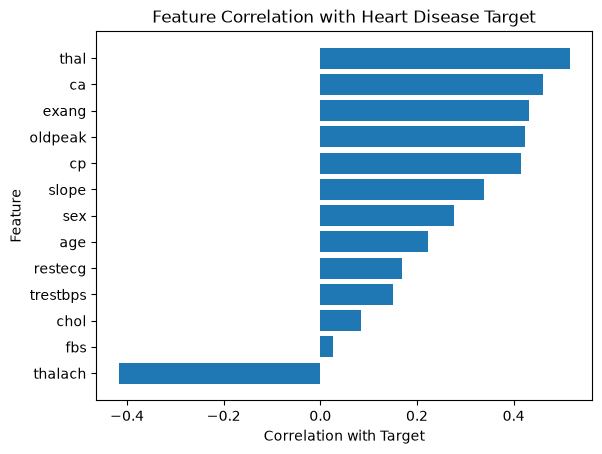

In [180]:
# Visualize correlations with the target


plt.barh(
    target_correlations.index,
    target_correlations.values
)

plt.xlabel("Correlation with Target")
plt.ylabel("Feature")
plt.title("Feature Correlation with Heart Disease Target")

plt.show()

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
What Does This Add?
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The correlation plot supports what appeared in the earlier boxplots. Features such as <code>oldpeak</code> and <code>thalach</code> already showed visible differences between patient groups, and the correlation values now confirm that these differences are also measurable.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
6. Do Any Numerical Features Contain Unusual Values?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Check for Outliers?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The earlier plots showed a few unusually high or low values in some numerical features.
<br><br>
Outliers can affect the interpretation of the data and may influence model performance, so I will use the <b>IQR method</b> to identify potential unusual values.
<br><br>
However, detecting an outlier does not automatically mean that it should be removed, especially because these values may represent real patient measurements.
</p>

</div>

</div>

In [181]:
# Count potential outliers using the IQR method
outlier_summary = {}

for feature in numerical_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary[feature] = len(outliers)

outlier_summary

{'age': 0, 'trestbps': 9, 'chol': 5, 'thalach': 1, 'oldpeak': 5}

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Most numerical features contain only a small number of potential outliers.
Resting blood pressure has the highest number with <b>9 outliers</b>, while cholesterol and oldpeak each have <b>5</b>.
Age has no detected outliers, and maximum heart rate has only <b>1</b>.
Since these values may represent real patient measurements, I will keep them in the dataset instead of removing them automatically.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
7. What Do the Categorical Features Tell Us?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Compare Categorical Features?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Some features in this dataset are stored as numbers, but the numbers actually represent categories rather than continuous measurements.
<br><br>
I will compare important categorical features such as <code>cp</code>, <code>exang</code>, <code>ca</code>, and <code>thal</code> with the target to see whether their category distributions differ between the two patient groups.
<br><br>
This can reveal patterns that may not be clear from numerical summaries alone.
</p>

</div>

</div>

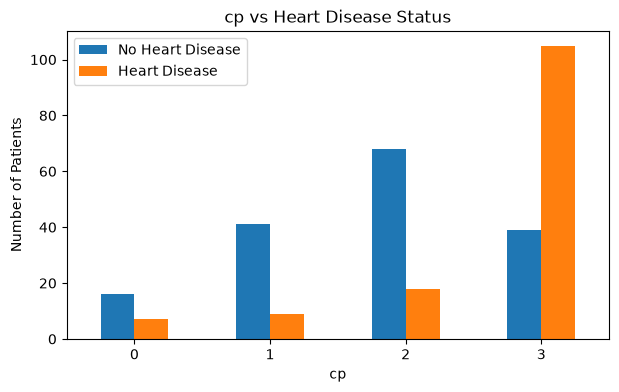

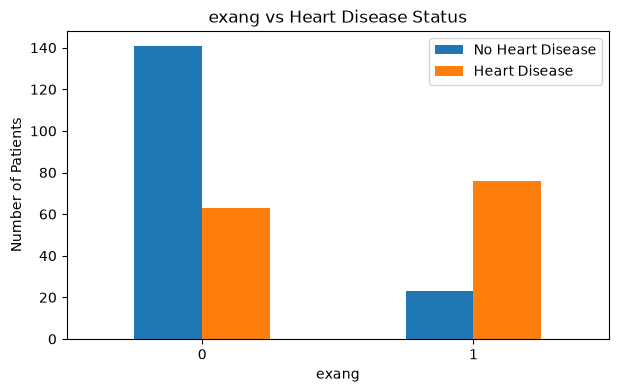

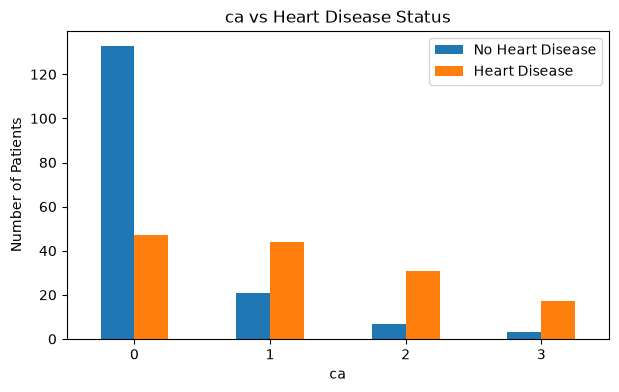

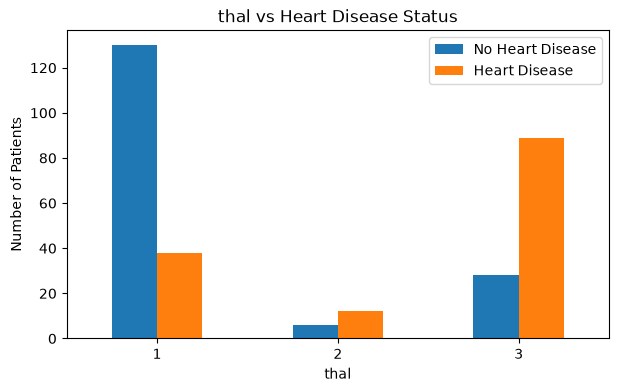

In [182]:
# Compare important categorical features with the target
categorical_features = ["cp", "exang", "ca", "thal"]

for feature in categorical_features:
    comparison = pd.crosstab(
        df[feature],
        df["target"]
    )

    comparison.plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.title(f"{feature} vs Heart Disease Status")
    plt.legend(["No Heart Disease", "Heart Disease"])
    plt.xticks(rotation=0)

    plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<ul style="color:#3F4A52;line-height:1.7;margin-bottom:0;">

<li>
For <code>cp</code>, category 3 appears much more often among patients with heart disease, while the other categories are more common in patients without heart disease.
</li>

<li>
Patients with exercise-induced angina (<code>exang = 1</code>) appear more frequently in the heart disease group.
</li>

<li>
For <code>ca</code>, patients with <code>ca = 0</code> are mostly in the no-heart-disease group, while higher values appear more often in the heart disease group.
</li>

<li>
The <code>thal</code> feature shows a clear difference between the groups. <code>thal = 1</code> is more common among patients without heart disease, while <code>thal = 3</code> appears much more often among patients with heart disease.
</li>

</ul>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
8. How Do Age and Maximum Heart Rate Interact?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
So far, I looked at each feature separately. Now I want to see whether age and maximum heart rate show a different pattern across the two target groups.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Question
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Do patients with heart disease follow a different age and maximum-heart-rate pattern?
</p>

</div>

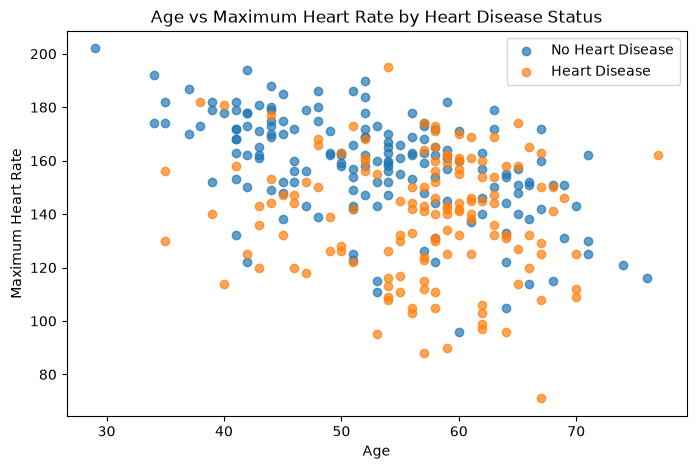

In [183]:
# Compare age and maximum heart rate by target group
plt.figure(figsize=(8, 5))

for target_value, label in [(0, "No Heart Disease"), (1, "Heart Disease")]:
    group = df[df["target"] == target_value]

    plt.scatter(
        group["age"],
        group["thalach"],
        label=label,
        alpha=0.7
    )

plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.title("Age vs Maximum Heart Rate by Heart Disease Status")
plt.legend()

plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The scatter plot shows that patients with heart disease are more concentrated in the older age range and often have lower maximum heart rates. However, the two groups still overlap, which means that age and maximum heart rate alone are not enough to clearly separate heart disease cases.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
9. Probability in Context
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
The target distribution can also be viewed as a simple probability: if one patient is selected randomly from this dataset, what is the probability that the patient belongs to the heart disease group?
</p>

</div>

In [184]:
# Estimate the probability of heart disease from the dataset
heart_disease_probability = (df["target"] == 1).mean()

print(
    "Probability of heart disease:",
    round(heart_disease_probability, 3)
)

print(
    "Percentage:",
    round(heart_disease_probability * 100, 1),
    "%"
)

Probability of heart disease: 0.459
Percentage: 45.9 %


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
About <b>45.9%</b> of the patients in this dataset belong to the heart disease group. This is close to half of the dataset, which supports the earlier observation that the target classes are fairly balanced.
</p>

</div>

<h2 style="color:#16324F;font-weight:bold;">
Milestone 2 Takeaway
</h2>

<div style="
    background:linear-gradient(135deg,#F8FBFC,#EAF3F5);
    border:1px solid #D5E5E9;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52;margin:0;">
The exploratory analysis revealed several useful patterns related to heart disease while also showing considerable overlap between the two patient groups. The dataset is now better understood and ready for the next stage, where a supervised classification model will be trained and evaluated.
</p>

</div>

<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 3 — Supervised Learning & Baseline Model
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
From understanding patient patterns to building the first prediction model
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52;margin:0;">
The exploratory analysis revealed several patterns related to heart disease, but also showed that no single feature can clearly separate the two patient groups. The next step is to see whether these features can work together in a classification model.
</p>

</div>

<h2 style="color:#2F6F7E;">
1. Defining the Prediction Problem
</h2>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Target
</p>

<p style="color:#3F4A52;margin-bottom:0;">
<code>target = 0</code> means no heart disease, while <code>target = 1</code> means heart disease.
</p>

</div>

In [185]:
# Separate the input features from the target
X = df.drop("target", axis=1)
y = df["target"]

print("Input features shape:", X.shape)
print("Target shape:", y.shape)

Input features shape: (303, 13)
Target shape: (303,)


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The dataset now contains <b>13 input features</b> in <code>X</code> and one binary target in <code>y</code>. These variables are ready to be split into training and testing sets.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
2. Train/Test Split
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="color:#3F4A52;margin:0;">
To evaluate the model fairly, I will keep part of the data unseen during training and use it only for final testing.
</p>

</div>

In [186]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (242, 13)
Testing set: (61, 13)

Training target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64

Testing target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The dataset was split into <b>80% training data</b> and <b>20% testing data</b>. Stratification keeps the heart disease class proportions similar in both sets, giving a fairer evaluation later.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
3. Building the Baseline Model
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Logistic Regression?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
I will start with Logistic Regression as the baseline model because it is simple, easy to interpret, and suitable for binary classification.
<br><br>
It gives me a clear starting point that I can later compare with a more flexible model.
<br><br>
Since the features have different numerical scales, <code>StandardScaler</code> will be applied before training.
</p>

</div>

In [187]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the training and testing features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the baseline Logistic Regression model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

# Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_predictions[:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

<h2 style="color:#2F6F7E;font-weight:bold;">
4. How Well Does the Baseline Model Perform?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Use More Than Accuracy?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Accuracy shows the overall percentage of correct predictions, but it does not explain what types of mistakes the model makes.
<br><br>
For this classification task, I will also use <b>precision</b>, <b>recall</b>, and <b>F1-score</b> to get a more complete view of model performance.
<br><br>
Recall is especially useful for showing how many actual heart disease cases are detected, while F1-score balances precision and recall in one metric.
</p>

</div>

In [188]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate baseline evaluation metrics
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print("Baseline Accuracy:", round(baseline_accuracy, 3))
print("Baseline Precision:", round(baseline_precision, 3))
print("Baseline Recall:", round(baseline_recall, 3))
print("Baseline F1-score:", round(baseline_f1, 3))

Baseline Accuracy: 0.869
Baseline Precision: 0.812
Baseline Recall: 0.929
Baseline F1-score: 0.867


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The baseline Logistic Regression model achieved an accuracy of about <b>0.869</b> and an F1-score of about <b>0.867</b>. Its recall is especially high at <b>0.929</b>, meaning that the model correctly identified most of the patients in the heart disease class. Precision is slightly lower at <b>0.812</b>, which means that some patients were predicted as having heart disease even though they belonged to the other class.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
5. Where Does the Baseline Model Make Mistakes?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Use a Confusion Matrix?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The evaluation metrics summarize the model performance, but they do not show exactly where the prediction errors occur.
<br><br>
A confusion matrix separates the predictions into <b>true positives</b>, <b>true negatives</b>, <b>false positives</b>, and <b>false negatives</b>.
<br><br>
For this project, false negatives are especially important because they represent heart disease cases that the model predicted as no heart disease.
</p>

</div>

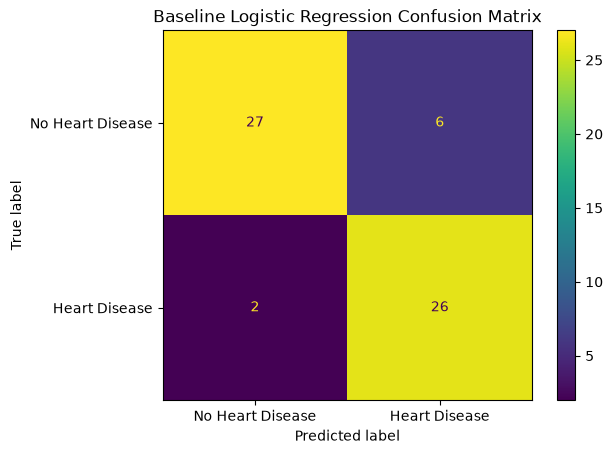

In [189]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    display_labels=["No Heart Disease", "Heart Disease"]
)

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The confusion matrix shows that the model correctly classified <b>27 patients without heart disease</b> and <b>26 patients with heart disease</b>.

It made <b>6 false positive predictions</b>, where patients without heart disease were predicted as having it, and only <b>2 false negative predictions</b>, where patients with heart disease were missed.

The small number of false negatives explains the model's high recall of <b>0.929</b>.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Classification Report
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The overall metrics summarize the model performance, but I also want to check how the model performs for each class separately.
<br><br>
The classification report shows the precision, recall, and F1-score for both patients with and without heart disease.
</p>

</div>

In [190]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.93      0.82      0.87        33
   Heart Disease       0.81      0.93      0.87        28

        accuracy                           0.87        61
       macro avg       0.87      0.87      0.87        61
    weighted avg       0.88      0.87      0.87        61



<div style="
    background:#F6F9FA;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:16px;
    margin:0 0 8px 0;
">
Observation
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The classification report shows balanced performance across both classes.
<br><br>
For the <b>No Heart Disease</b> class, the model achieved a precision of <b>0.93</b>, recall of <b>0.82</b>, and F1-score of <b>0.87</b>.
<br><br>
For the <b>Heart Disease</b> class, recall was higher at <b>0.93</b>, while precision was <b>0.81</b>. This means the model detected most heart disease cases, although some patients without heart disease were incorrectly predicted as positive.
<br><br>
The F1-score is about <b>0.87</b> for both classes, showing fairly balanced classification performance.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#F8FBFC,#EAF3F5);
    border:1px solid #D5E5E9;
    border-radius:12px;
    padding:15px 17px;
    margin:10px 0 22px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Milestone 3 Takeaway
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Logistic Regression provided a strong first baseline, reaching an F1-score of <b>0.867</b> and correctly identifying most heart disease cases. The next step is to test a different classifier and see whether it can improve on this baseline.
</p>

</div>

<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 4 — Model Comparison & Cross-Validation
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
Can another classifier perform better than the Logistic Regression baseline?
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 14px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Random Forest?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Logistic Regression provides a useful baseline, but it mainly learns linear relationships between the features and the target.
<br><br>
To test whether a model that can capture more complex patterns performs better, I will use Random Forest as the second classifier.
<br><br>
Both models will be evaluated using the same training and testing data and the same classification metrics to keep the comparison fair.
</p>

</div>

In [191]:
from sklearn.ensemble import RandomForestClassifier

# Create the comparison model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train using the same training set
random_forest.fit(X_train, y_train)

# Predict the same held-out test set
rf_predictions = random_forest.predict(X_test)

rf_predictions[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

<h2 style="color:#2F6F7E;font-weight:bold;">
2. Random Forest Performance
</h2>

In [192]:
# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy, 3))
print("Random Forest Precision:", round(rf_precision, 3))
print("Random Forest Recall:", round(rf_recall, 3))
print("Random Forest F1-score:", round(rf_f1, 3))

Random Forest Accuracy: 0.885
Random Forest Precision: 0.839
Random Forest Recall: 0.929
Random Forest F1-score: 0.881


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The Random Forest model achieved an accuracy of <b>0.885</b> and an F1-score of <b>0.881</b>. Its recall remained high at <b>0.929</b>, while precision improved to <b>0.839</b>. Compared with the Logistic Regression baseline, Random Forest performed slightly better overall.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Classification Report
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
To examine the Random Forest model more closely, I will check its performance for each class separately.
<br><br>
The classification report shows the precision, recall, and F1-score for both heart disease classes.
</p>

</div>

In [193]:
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61



<div style="
    background:#F6F9FA;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:16px;
    margin:0 0 8px 0;
">
Observation
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The Random Forest classification report shows strong performance across both classes.
<br><br>
For the <b>No Heart Disease</b> class, the model achieved a precision of <b>0.93</b>, recall of <b>0.85</b>, and F1-score of <b>0.89</b>.
<br><br>
For the <b>Heart Disease</b> class, recall remained high at <b>0.93</b>, while precision improved to <b>0.84</b> with an F1-score of <b>0.88</b>.
<br><br>
Compared with Logistic Regression, Random Forest gives slightly better overall class-level performance while still identifying most heart disease cases.
</p>

</div>

In [194]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [baseline_accuracy, rf_accuracy],
    "Precision": [baseline_precision, rf_precision],
    "Recall": [baseline_recall, rf_recall],
    "F1-score": [baseline_f1, rf_f1]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.869,0.812,0.929,0.867
1,Random Forest,0.885,0.839,0.929,0.881


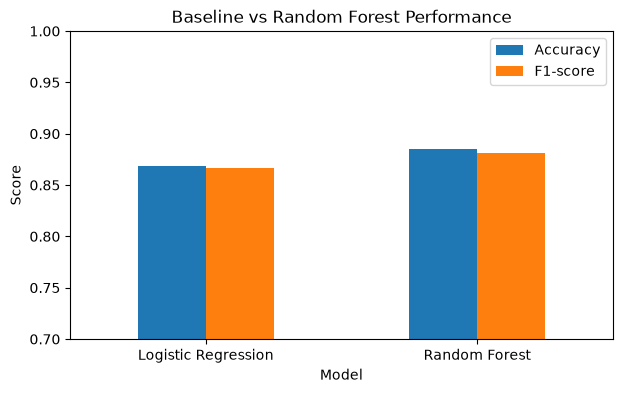

In [195]:
comparison_plot = model_comparison.set_index("Model")[["Accuracy", "F1-score"]]

comparison_plot.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Score")
plt.title("Baseline vs Random Forest Performance")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.legend()
plt.show()

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Comparison
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Random Forest slightly outperformed Logistic Regression in both accuracy and F1-score, while both models achieved the same recall. This makes Random Forest the stronger model on this test split, but cross-validation is still needed to check whether this improvement is consistent.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
3. How Does Tree Depth Affect Random Forest Performance?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Test Different Tree Depths?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Random Forest can build very deep trees, which may fit the training data more closely.
<br><br>
To understand how model complexity affects performance, I will test several values of <code>max_depth</code> and compare the training and validation F1-scores.
<br><br>
A large gap between the two scores may suggest overfitting, while similar scores can indicate better generalization.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:12px 14px;
    margin:10px 0 14px 0;
">
<b style="color:#2F6F7E;">Note:</b><br>

The same training and validation data are used for every depth value so the comparison remains fair.
</div>

In [196]:
# Create a validation set from the training data
X_depth_train, X_depth_val, y_depth_train, y_depth_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

depth_results = []

for depth in range(2, 11):

    rf_depth_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    rf_depth_model.fit(
        X_depth_train,
        y_depth_train
    )

    train_predictions = rf_depth_model.predict(
        X_depth_train
    )

    val_predictions = rf_depth_model.predict(
        X_depth_val
    )

    train_f1 = f1_score(
        y_depth_train,
        train_predictions
    )

    val_f1 = f1_score(
        y_depth_val,
        val_predictions
    )

    depth_results.append({
        "Max Depth": depth,
        "Training F1": train_f1,
        "Validation F1": val_f1,
        "Gap": train_f1 - val_f1
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df.round(3)

,Max Depth,Training F1,Validation F1,Gap
0,2,0.826,0.850,-0.024
1,3,0.838,0.821,0.018
2,4,0.867,0.829,0.038
3,5,0.929,0.829,0.100
4,6,0.977,0.810,0.168
5,7,0.994,0.773,0.222
6,8,1.000,0.791,0.209
7,9,1.000,0.810,0.190
8,10,1.000,0.800,0.200


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="
    color:#3F4A52;
    margin-bottom:0;
    line-height:1.7;
">
The effect of <code>max_depth</code> is clearly visible in the results.
<br><br>
At depth <b>2</b>, the model achieved the highest validation F1-score of <b>0.850</b>, while the training F1-score was <b>0.826</b>.
<br><br>
As the trees became deeper, the training F1-score continued to increase and reached <b>1.000</b> from depth <b>8</b> onward.
<br><br>
However, the validation F1-score did not improve with deeper trees. The gap between training and validation performance became much larger, especially from depth <b>6</b> onward.
<br><br>
This suggests that deeper trees fit the training data more closely but generalize less effectively to unseen validation data.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Cross-Validation?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The test split showed that Random Forest performed slightly better than Logistic Regression, but one train/test split may not represent the full dataset.
<br><br>
To get a more reliable comparison, I will use <b>5-fold cross-validation</b>. This evaluates each model on several different validation subsets instead of relying on one result only.
<br><br>
I will use <b>StratifiedKFold</b> so that the proportion of the two target classes stays similar across all folds.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:12px 14px;
    margin:10px 0 14px 0;
">

<b style="color:#2F6F7E;">Note:</b><br>
This plot makes it easier to compare how training and testing performance change as the trees become deeper.

</div>

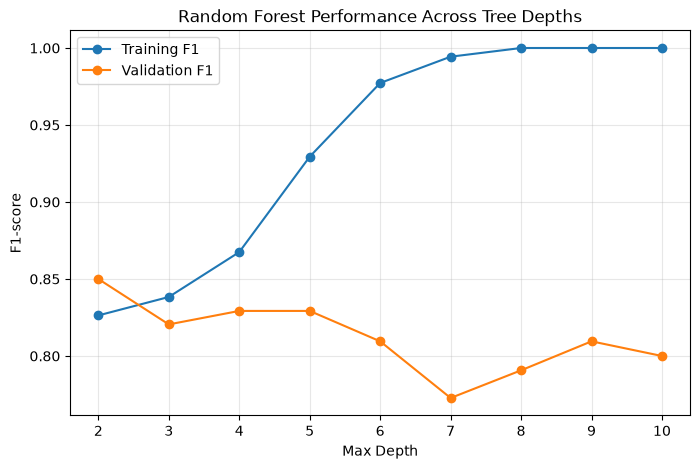

In [197]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Training F1"],
    marker="o",
    label="Training F1"
)

plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Validation F1"],
    marker="o",
    label="Validation F1"
)

plt.xlabel("Max Depth")
plt.ylabel("F1-score")
plt.title("Random Forest Performance Across Tree Depths")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Plot Analysis
</p>

<p style="
    color:#3F4A52;
    margin-bottom:0;
    line-height:1.7;
">
The training F1-score increases steadily as <code>max_depth</code> becomes larger and reaches <b>1.000</b> from depth <b>8</b> onward.
<br><br>
The validation F1-score does not follow the same pattern. Its highest value is about <b>0.850</b> at depth <b>2</b>, then it generally stays lower as the trees become deeper.
<br><br>
The growing gap between training and validation performance shows that deeper trees fit the training data very closely without improving validation performance, which is a sign of overfitting.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
4. Which Features Matter Most to the Random Forest?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Check Feature Importance?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Random Forest can estimate how much each input feature contributes to its predictions.
<br><br>
Looking at feature importance helps connect the model results with the patterns already seen during EDA.
<br><br>
I will rank the features from most to least important to see which patient variables influenced the model the most.
</p>

</div>

In [198]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.round(3)

,Feature,Importance
7,thalach,0.135
2,cp,0.127
12,thal,0.123
11,ca,0.101
0,age,0.091
9,oldpeak,0.089
4,chol,0.089
3,trestbps,0.081
8,exang,0.051
10,slope,0.047


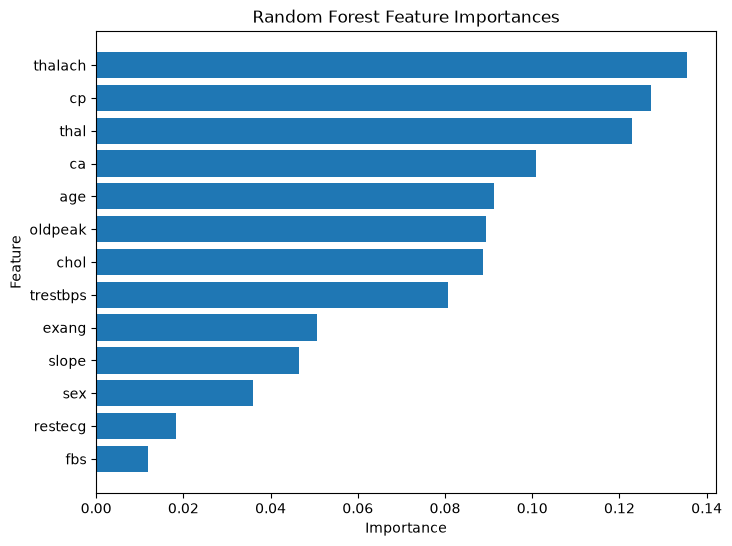

In [199]:
plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")

plt.gca().invert_yaxis()

plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="
    color:#3F4A52;
    margin-bottom:0;
    line-height:1.7;
">
The Random Forest model gives the highest importance to <code>thalach</code>, followed by <code>cp</code> and <code>thal</code>.
<br><br>
Features such as <code>ca</code>, <code>age</code>, <code>oldpeak</code>, and <code>chol</code> also contribute noticeably to the model.
<br><br>
On the other hand, <code>fbs</code>, <code>restecg</code>, and <code>sex</code> have lower importance compared with the other features.
<br><br>
This partly supports the earlier EDA results, where <code>thal</code>, <code>ca</code>, <code>oldpeak</code>, and <code>thalach</code> showed clear relationships with the target.
</p>

</div>

In [200]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression cross-validation
logistic_cv_scores = []

for train_index, val_index in cv.split(X_train, y_train):
    X_fold_train = X_train.iloc[train_index]
    X_fold_val = X_train.iloc[val_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_val = y_train.iloc[val_index]

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_val_scaled = fold_scaler.transform(X_fold_val)

    fold_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    fold_model.fit(X_fold_train_scaled, y_fold_train)

    fold_predictions = fold_model.predict(X_fold_val_scaled)

    logistic_cv_scores.append(
        f1_score(y_fold_val, fold_predictions)
    )

logistic_cv_scores = np.array(logistic_cv_scores)

# Random Forest cross-validation
rf_cv_scores = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression CV F1-scores:")
print(logistic_cv_scores)
print("Mean:", round(logistic_cv_scores.mean(), 3))

print("\nRandom Forest CV F1-scores:")
print(rf_cv_scores)
print("Mean:", round(rf_cv_scores.mean(), 3))

Logistic Regression CV F1-scores:
[0.86956522 0.76923077 0.7804878  0.8        0.80952381]
Mean: 0.806

Random Forest CV F1-scores:
[0.79166667 0.76923077 0.78947368 0.80851064 0.71428571]
Mean: 0.775


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Across the five folds, Logistic Regression achieved a higher mean F1-score of <b>0.806</b>, compared with <b>0.775</b> for Random Forest.

Although Random Forest performed slightly better on the held-out test set, Logistic Regression showed stronger average performance across the cross-validation folds. This shows why evaluating a model on more than one split gives a more complete picture of its performance.
</p>

</div>

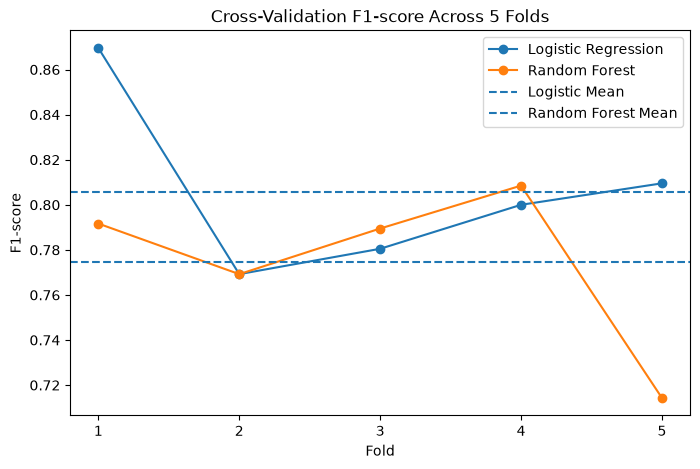

In [201]:
# Compare F1-score across the five cross-validation folds
folds = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 5))

plt.plot(
    folds,
    logistic_cv_scores,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    folds,
    rf_cv_scores,
    marker="o",
    label="Random Forest"
)

plt.axhline(
    logistic_cv_scores.mean(),
    linestyle="--",
    label="Logistic Mean"
)

plt.axhline(
    rf_cv_scores.mean(),
    linestyle="--",
    label="Random Forest Mean"
)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Cross-Validation F1-score Across 5 Folds")
plt.xticks(folds)
plt.legend()

plt.show()

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
What Does the Comparison Show?
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The fold-by-fold results vary for both models, but Logistic Regression maintains the higher average F1-score. Random Forest drops more noticeably in the fifth fold, which lowers its overall cross-validation mean.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Comparing Prediction Errors
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Random Forest achieved slightly better test performance, but I also want to see whether it makes fewer prediction errors than Logistic Regression.
<br><br>
I will compare its confusion matrix with the baseline model, focusing on the number of false positives and false negatives.
</p>

</div>

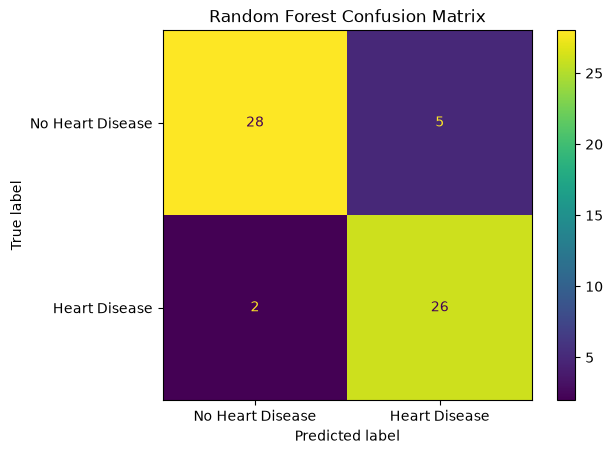

In [202]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["No Heart Disease", "Heart Disease"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The Random Forest model correctly classified <b>28 patients without heart disease</b> and <b>26 patients with heart disease</b>.

It produced <b>5 false positives</b> and <b>2 false negatives</b>. Compared with Logistic Regression, Random Forest reduced the number of false positives from <b>6 to 5</b>, while keeping the same number of false negatives.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
5. Can Hyperparameter Tuning Improve Random Forest?
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Tune the Model?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The previous experiments showed that Random Forest performance changes when its tree depth changes.
<br><br>
Instead of selecting one setting manually, I will use <b>GridSearchCV</b> to test several combinations of hyperparameters using cross-validation.
<br><br>
The best combination will be selected using the <b>F1-score</b>, then evaluated once on the held-out test set.
</p>

</div>

In [203]:
from sklearn.model_selection import GridSearchCV

# Define a small hyperparameter search space
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5]
}

# Create a fresh Random Forest model
rf_for_tuning = RandomForestClassifier(
    random_state=42
)

# Search for the best combination using cross-validation
grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "\nBest CV F1-score:",
    round(grid_search.best_score_, 3)
)

Best Parameters:
{'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}

Best CV F1-score: 0.799


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Tuning Result
</p>

<p style="
    color:#3F4A52;
    margin-bottom:0;
    line-height:1.7;
">
GridSearchCV selected <code>max_depth = 7</code>, <code>min_samples_split = 2</code>, and <code>n_estimators = 200</code> as the best Random Forest configuration.
<br><br>
The best cross-validation F1-score reached <b>0.799</b>, which is higher than the original Random Forest mean CV F1-score of about <b>0.775</b>.
<br><br>
This shows that tuning improved the Random Forest's average validation performance, although Logistic Regression still achieved a slightly higher mean CV F1-score of about <b>0.806</b>.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
What Did Tuning Improve?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The tuned Random Forest achieved the strongest held-out test performance in the project, with an accuracy of <b>0.902</b>, recall of <b>0.964</b>, and F1-score of <b>0.900</b>.
<br><br>
Its cross-validation F1-score also improved from about <b>0.775</b> to <b>0.799</b>.
<br><br>
Therefore, the tuned Random Forest becomes the strongest model on the final test set, while Logistic Regression remains slightly stronger in average cross-validation performance.
</p>

</div>

In [204]:
# Get the best model found by GridSearchCV
tuned_random_forest = grid_search.best_estimator_

# Evaluate it on the held-out test set
tuned_rf_predictions = tuned_random_forest.predict(X_test)

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_predictions
)

print("Tuned RF Accuracy:", round(tuned_rf_accuracy, 3))
print("Tuned RF Precision:", round(tuned_rf_precision, 3))
print("Tuned RF Recall:", round(tuned_rf_recall, 3))
print("Tuned RF F1-score:", round(tuned_rf_f1, 3))

Tuned RF Accuracy: 0.902
Tuned RF Precision: 0.844
Tuned RF Recall: 0.964
Tuned RF F1-score: 0.9


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="
    color:#2F6F7E;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="
    color:#3F4A52;
    margin-bottom:0;
    line-height:1.7;
">
The tuned Random Forest improved the held-out test performance.
<br><br>
Its accuracy increased to <b>0.902</b> and the F1-score reached <b>0.900</b>.
<br><br>
Recall also increased to <b>0.964</b>, meaning that the tuned model detected almost all heart disease cases in the test set.
<br><br>
Precision remained strong at <b>0.844</b>. Overall, hyperparameter tuning produced a better balance of performance than the original Random Forest model.
</p>

</div>

In [205]:
rf_tuning_comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        rf_accuracy,
        tuned_rf_accuracy
    ],
    "Precision": [
        rf_precision,
        tuned_rf_precision
    ],
    "Recall": [
        rf_recall,
        tuned_rf_recall
    ],
    "F1-score": [
        rf_f1,
        tuned_rf_f1
    ]
})

rf_tuning_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Original Random Forest,0.885,0.839,0.929,0.881
1,Tuned Random Forest,0.902,0.844,0.964,0.900


<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Final Tuning Comparison
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Compared with the original Random Forest, the tuned version improved accuracy from <b>0.885</b> to <b>0.902</b> and F1-score from <b>0.881</b> to <b>0.900</b>.
<br><br>
Recall also increased from <b>0.929</b> to <b>0.964</b>, showing that the tuned model missed fewer heart disease cases on the test set.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Use ROC Curve and ROC-AUC?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
Accuracy, precision, recall, and F1-score evaluate the models using one classification threshold.
<br><br>
The <b>ROC curve</b> provides another view by showing the relationship between the true positive rate and false positive rate across different thresholds.
<br><br>
The <b>ROC-AUC score</b> summarizes this performance in one value and helps compare how well the two models separate the heart disease and no-heart-disease classes.
</p>

</div>

In [206]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for the positive class
logistic_probabilities = baseline_model.predict_proba(
    X_test_scaled
)[:, 1]

rf_probabilities = random_forest.predict_proba(
    X_test
)[:, 1]

# Calculate ROC-AUC scores
logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print(
    "Logistic Regression ROC-AUC:",
    round(logistic_auc, 3)
)

print(
    "Random Forest ROC-AUC:",
    round(rf_auc, 3)
)

Logistic Regression ROC-AUC: 0.953
Random Forest ROC-AUC: 0.954


**Note:**  
I will plot the ROC curves for both models to compare how well they separate the two classes.

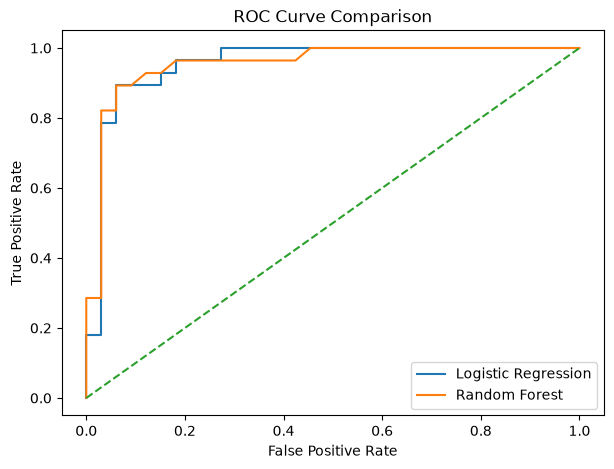

In [207]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(logistic_fpr, logistic_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
Both models achieved very high ROC-AUC scores, with <b>0.953</b> for Logistic Regression and <b>0.954</b> for Random Forest.

The two ROC curves are very close, which shows that both models separate the two classes very well across different classification thresholds. Random Forest achieved a slightly higher ROC-AUC, but the difference is very small.
</p>

</div>

<h2 style="color:#16324F;font-weight:bold;">
Milestone 4 Takeaway
</h2>

<div style="
    background:linear-gradient(135deg,#F8FBFC,#EAF3F5);
    border:1px solid #D5E5E9;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 22px 0;
">
<p style="color:#3F4A52;margin:0;">
<p style="color:#3F4A52;margin:0;line-height:1.7;">
The original Random Forest performed slightly better than Logistic Regression on the held-out test set, with an F1-score of <b>0.881</b> compared with <b>0.867</b>.
<br><br>
Cross-validation showed a different pattern, where Logistic Regression achieved a higher mean F1-score of <b>0.806</b> compared with <b>0.775</b> for the original Random Forest.
<br><br>
After hyperparameter tuning, the Random Forest improved to a mean cross-validation F1-score of <b>0.799</b> and achieved the strongest held-out test F1-score of <b>0.900</b>.
<br><br>
Overall, the tuned Random Forest gave the best final test performance, while Logistic Regression remained slightly stronger across the cross-validation folds.
</p>
</p>

</div>

<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 5 — Feature Engineering & Reusable Pipeline
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
Can a cleaner feature setup and a reusable workflow improve the modeling process?
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#3F4A52;margin:0;">
The previous milestone compared Logistic Regression and Random Forest. Now I will improve the workflow by creating a small engineered feature and then combining preprocessing and modeling into one reusable Pipeline.
</p>

</div>

<h2 style="color:#2F6F7E;font-weight:bold;">
1. Creating a Simple Engineered Feature
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Create a New Feature?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
During EDA, both <b>age</b> and <b>maximum heart rate (thalach)</b> showed useful patterns related to the target.
<br><br>
Instead of using them only as separate features, I will create <code>thalach_age_ratio</code> to represent maximum heart rate relative to the patient's age.
<br><br>
The goal is to test whether combining these two related measurements gives the model additional useful information.
</p>

</div>

In [208]:
# Create a copy before feature engineering
X_engineered = X.copy()

# Maximum heart rate relative to age
X_engineered["thalach_age_ratio"] = (
    X_engineered["thalach"] / X_engineered["age"]
)

X_engineered[["age", "thalach", "thalach_age_ratio"]].head()

,age,thalach,thalach_age_ratio
0,63,150,2.380952
1,67,108,1.611940
2,67,129,1.925373
3,37,187,5.054054
4,41,172,4.195122


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The new <code>thalach_age_ratio</code> feature combines maximum heart rate with age into one value. The first rows show that the ratio changes noticeably across patients, so it may provide additional information for the classification model.
</p>

</div>

In [209]:
# Split the engineered feature set using the same settings
X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X_engineered,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Engineered training set:", X_eng_train.shape)
print("Engineered testing set:", X_eng_test.shape)

Engineered training set: (242, 14)
Engineered testing set: (61, 14)


<h2 style="color:#2F6F7E;font-weight:bold;">
2. Building a Reusable Pipeline
</h2>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Use a Scikit-learn Pipeline?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
In the baseline model, scaling and model training were performed as separate steps.
<br><br>
A Scikit-learn <b>Pipeline</b> combines these steps into one workflow, so the same preprocessing is automatically applied whenever the model is trained or used for prediction.
<br><br>
This makes the workflow cleaner, more consistent, easier to repeat, and reduces the risk of applying preprocessing differently between training and testing data.
</p>

</div>

In [210]:
from sklearn.pipeline import Pipeline

# Build a reusable pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the full pipeline
logistic_pipeline.fit(
    X_eng_train,
    y_eng_train
)

# Make predictions
pipeline_predictions = logistic_pipeline.predict(
    X_eng_test
)

pipeline_predictions[:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

In [211]:
pipeline_accuracy = accuracy_score(
    y_eng_test,
    pipeline_predictions
)

pipeline_precision = precision_score(
    y_eng_test,
    pipeline_predictions
)

pipeline_recall = recall_score(
    y_eng_test,
    pipeline_predictions
)

pipeline_f1 = f1_score(
    y_eng_test,
    pipeline_predictions
)

print("Pipeline Accuracy:", round(pipeline_accuracy, 3))
print("Pipeline Precision:", round(pipeline_precision, 3))
print("Pipeline Recall:", round(pipeline_recall, 3))
print("Pipeline F1-score:", round(pipeline_f1, 3))

Pipeline Accuracy: 0.869
Pipeline Precision: 0.812
Pipeline Recall: 0.929
Pipeline F1-score: 0.867


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The Pipeline achieved the same performance as the original Logistic Regression baseline, with an accuracy of <b>0.869</b> and an F1-score of <b>0.867</b>.

This means that the new <code>thalach_age_ratio</code> feature did not improve the test performance in this experiment. However, the Pipeline makes the preprocessing and model training cleaner and easier to repeat.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
Why Try a Second Feature?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The first engineered feature did not improve the Logistic Regression results, so I will test a second interaction instead of stopping after one attempt.
<br><br>
During EDA, both <b>age</b> and <b>oldpeak</b> showed noticeable relationships with the target.
<br><br>
I will combine them into <code>age_oldpeak_interaction</code> to test whether their interaction provides information that the original features alone did not capture.
</p>

</div>

In [212]:
# Add a second engineered feature
X_engineered_v2 = X.copy()

X_engineered_v2["thalach_age_ratio"] = (
    X_engineered_v2["thalach"] / X_engineered_v2["age"]
)

X_engineered_v2["age_oldpeak_interaction"] = (
    X_engineered_v2["age"] * X_engineered_v2["oldpeak"]
)

X_engineered_v2[
    ["age", "oldpeak", "age_oldpeak_interaction"]
].head()

,age,oldpeak,age_oldpeak_interaction
0,63,2.3,144.9
1,67,1.5,100.5
2,67,2.6,174.2
3,37,3.5,129.5
4,41,1.4,57.4


In [213]:
X_eng2_train, X_eng2_test, y_eng2_train, y_eng2_test = train_test_split(
    X_engineered_v2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [214]:
pipeline_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

pipeline_v2.fit(
    X_eng2_train,
    y_eng2_train
)

pipeline_v2_predictions = pipeline_v2.predict(
    X_eng2_test
)

In [215]:
pipeline_v2_accuracy = accuracy_score(
    y_eng2_test,
    pipeline_v2_predictions
)

pipeline_v2_precision = precision_score(
    y_eng2_test,
    pipeline_v2_predictions
)

pipeline_v2_recall = recall_score(
    y_eng2_test,
    pipeline_v2_predictions
)

pipeline_v2_f1 = f1_score(
    y_eng2_test,
    pipeline_v2_predictions
)

print("Pipeline V2 Accuracy:", round(pipeline_v2_accuracy, 3))
print("Pipeline V2 Precision:", round(pipeline_v2_precision, 3))
print("Pipeline V2 Recall:", round(pipeline_v2_recall, 3))
print("Pipeline V2 F1-score:", round(pipeline_v2_f1, 3))

Pipeline V2 Accuracy: 0.869
Pipeline V2 Precision: 0.812
Pipeline V2 Recall: 0.929
Pipeline V2 F1-score: 0.867


<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Observation
</p>

<p style="color:#3F4A52;margin-bottom:0;">
The second engineered feature also produced the same model performance, with an F1-score of <b>0.867</b>.

This suggests that the original features already contain most of the useful information needed by Logistic Regression, and these additional interactions did not provide a measurable improvement on the test set.
</p>

</div>

In [216]:
feature_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Pipeline V1",
        "Pipeline V2"
    ],
    "Accuracy": [
        baseline_accuracy,
        pipeline_accuracy,
        pipeline_v2_accuracy
    ],
    "Precision": [
        baseline_precision,
        pipeline_precision,
        pipeline_v2_precision
    ],
    "Recall": [
        baseline_recall,
        pipeline_recall,
        pipeline_v2_recall
    ],
    "F1-score": [
        baseline_f1,
        pipeline_f1,
        pipeline_v2_f1
    ]
})

feature_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline Logistic Regression,0.869,0.812,0.929,0.867
1,Pipeline V1,0.869,0.812,0.929,0.867
2,Pipeline V2,0.869,0.812,0.929,0.867


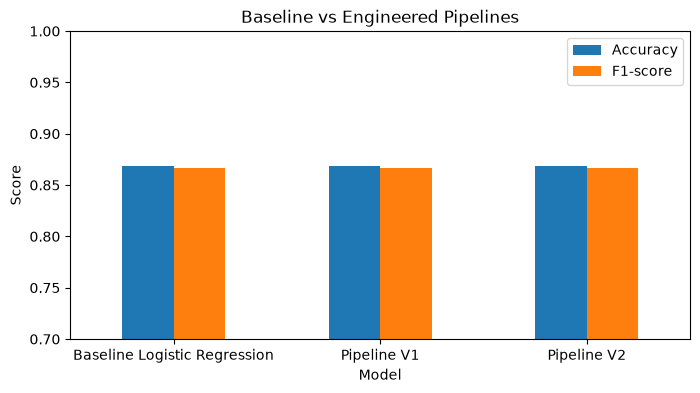

In [217]:
feature_comparison.set_index("Model")[["Accuracy", "F1-score"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.ylabel("Score")
plt.title("Baseline vs Engineered Pipelines")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.show()

<div style="
    background:#F6F9FA;
    border-left:4px solid #2F6F7E;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 18px 0;
">

<p style="color:#16324F;font-weight:bold;margin-top:0;">
Final Comparison
</p>

<p style="color:#3F4A52;margin-bottom:0;">
All three versions achieved the same test performance. The engineered features did not improve the Logistic Regression results, but the Pipeline created a cleaner and more repeatable workflow for preprocessing and model training.
</p>

</div>

<h2 style="color:#16324F;font-weight:bold;">
Milestone 5 Takeaway
</h2>

<div style="
    background:linear-gradient(135deg,#F8FBFC,#EAF3F5);
    border:1px solid #D5E5E9;
    border-radius:12px;
    padding:16px 18px;
    margin:10px 0 22px 0;
">

<p style="color:#3F4A52;margin:0;">
Two simple engineered features were tested, but neither improved the Logistic Regression test performance. The main improvement in this milestone was the use of a Scikit-learn Pipeline, which combined scaling and modeling into one consistent workflow.
</p>

</div>

<div style="
    background:#16324F;
    border-radius:12px;
    padding:18px 20px;
    margin:26px 0 18px 0;
">

<h2 style="color:white;margin:0;">
Milestone 7 — Final Review & Project Summary
</h2>

<p style="color:#EAF3F5;margin:7px 0 0 0;">
Bringing the full analysis together into one clear and reproducible final project
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 8px 0;
">
How Will the Final Model Be Selected?
</p>

<p style="
    color:#3F4A52;
    margin:0;
    line-height:1.7;
">
The project tested Logistic Regression, Random Forest, a Tuned Random Forest, and two engineered Pipeline versions.
<br><br>
The final decision will not depend on accuracy alone. I will consider <b>F1-score</b>, <b>recall</b>, <b>cross-validation performance</b>, and <b>ROC-AUC</b> together to get a more complete view of model performance.
<br><br>
This makes it possible to compare strong test-set performance with consistency across different validation folds.
</p>

</div>

In [218]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Pipeline V1",
        "Pipeline V2"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_accuracy,
        tuned_rf_accuracy,
        pipeline_accuracy,
        pipeline_v2_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_precision,
        tuned_rf_precision,
        pipeline_precision,
        pipeline_v2_precision
    ],
    "Recall": [
        baseline_recall,
        rf_recall,
        tuned_rf_recall,
        pipeline_recall,
        pipeline_v2_recall
    ],
    "F1-score": [
        baseline_f1,
        rf_f1,
        tuned_rf_f1,
        pipeline_f1,
        pipeline_v2_f1
    ]
})

final_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.869,0.812,0.929,0.867
1,Random Forest,0.885,0.839,0.929,0.881
2,Tuned Random Forest,0.902,0.844,0.964,0.900
3,Pipeline V1,0.869,0.812,0.929,0.867
4,Pipeline V2,0.869,0.812,0.929,0.867


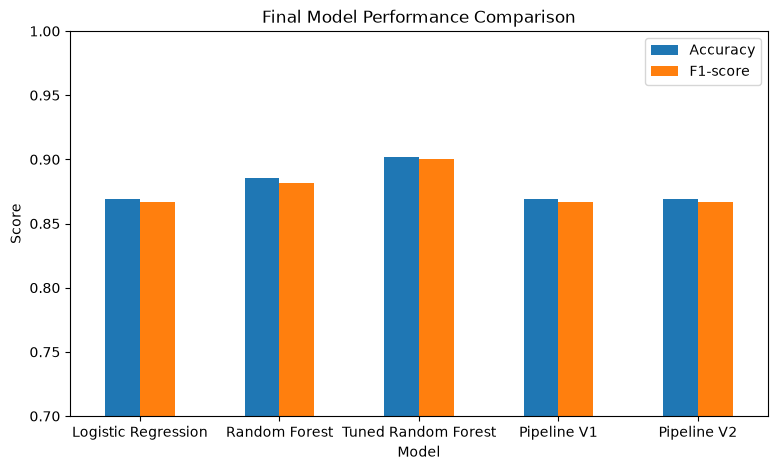

In [219]:
final_results.set_index("Model")[["Accuracy", "F1-score"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.title("Final Model Performance Comparison")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.show()

<div style="
    background:#EAF3F5;
    border:1px solid #D5E5E9;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0 18px 0;
">

<p style="color:#2F6F7E;font-weight:bold;margin-top:0;">
Final Observation
</p>

<p style="
    color:#3F4A52;
    margin-bottom:0;
    line-height:1.7;
">
The <b>Tuned Random Forest</b> achieved the strongest held-out test performance in the project.
<br><br>
It reached an accuracy of <b>0.902</b>, precision of <b>0.844</b>, recall of <b>0.964</b>, and an F1-score of <b>0.900</b>.
<br><br>
The original Random Forest achieved an F1-score of <b>0.881</b>, while Logistic Regression and both engineered Pipeline versions achieved about <b>0.867</b>.
<br><br>
Cross-validation gives a slightly different view. The Tuned Random Forest improved the Random Forest mean CV F1-score from about <b>0.775</b> to <b>0.799</b>, while Logistic Regression remained slightly higher at <b>0.806</b>.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 10px 0;
">
Key Findings
</p>

<div style="
    color:#3F4A52;
    line-height:1.8;
">

• The dataset contained <b>303 patient records</b> with no missing values or duplicate rows.<br><br>

• The target classes were fairly balanced, with about <b>45.9%</b> of the records belonging to the heart disease class.<br><br>

• During EDA, features such as <code>thal</code>, <code>ca</code>, <code>exang</code>, <code>oldpeak</code>, and <code>thalach</code> showed some of the clearest relationships with the target.<br><br>

• The <b>Tuned Random Forest</b> achieved the highest held-out test performance with an <b>F1-score of 0.900</b>, recall of <b>0.964</b>, and accuracy of <b>0.902</b>.<br><br>

• Hyperparameter tuning improved the Random Forest mean cross-validation F1-score from about <b>0.775</b> to <b>0.799</b>.<br><br>

• Logistic Regression achieved a slightly higher mean cross-validation F1-score of <b>0.806</b>, showing strong consistency across the folds.<br><br>

• Logistic Regression and the original Random Forest achieved very similar ROC-AUC scores, <b>0.953</b> and <b>0.954</b> respectively.<br><br>

• The engineered features did not improve Logistic Regression performance, but the Pipeline created a cleaner and more repeatable modeling workflow.

</div>

</div>

<div style="
    background:#F6F9FA;
    border:1px solid #DCE5E8;
    border-left:4px solid #2F6F7E;
    border-radius:10px;
    padding:14px 16px;
    margin:12px 0;
">

<p style="
    color:#16324F;
    font-weight:bold;
    font-size:17px;
    margin:0 0 10px 0;
">
Project Limitations
</p>

<div style="
    color:#3F4A52;
    line-height:1.8;
">

• The dataset contains only <b>303 patient records</b>, so the results may change when using a larger or more diverse dataset.<br><br>

• The models can only learn from the features available in the selected dataset.<br><br>

• The engineered features tested in this project did not improve the final model performance.<br><br>

• Model performance can vary across different data splits, which is why cross-validation was used in addition to the test set.<br><br>

• Although the models achieved strong evaluation scores on this dataset, the project is intended for <b>machine-learning analysis only</b> and should not be treated as a clinical diagnostic system.

</div>

</div>